# Data Visualization for Logfile

This project will visualize and bring insights from our processed parquet files, created with the source as our Apache logs.

### Imports and data reads

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns

Read our parquet file

In [7]:
df = pd.read_parquet("files/Apache.parquet")

df_polars = pl.from_pandas(df)
df_polars.head()

date,type,content,client
datetime[ns],str,str,str
2005-06-09 09:07:04,"""notice""","""LDAP: Built with OpenLDAP LDAP…",""""""
2005-06-09 09:07:04,"""notice""","""LDAP: SSL support unavailable""",""""""
2005-06-09 09:07:04,"""notice""","""suEXEC mechanism enabled (wrap…",""""""
2005-06-09 09:07:05,"""notice""","""Digest: generating secret for …",""""""
2005-06-09 09:07:05,"""notice""","""Digest: done""",""""""


Querying our volume of alerts with type categorization

In [4]:
count_by_date_df = (
    df_polars.with_columns(
        pl.col("date").dt.truncate("1mo").alias("year_month")
    )
    .group_by("year_month", "type")
    .agg(pl.col("type").count().alias("type_count"))
    .sort("year_month")
)

In [48]:
query_client="""
SELECT
    client,
    type,
    count(type) as type_count,
    FROM self
    WHERE client IS NOT NULL AND client <> '' AND type == 'error'
    GROUP BY client, type
    ORDER BY type_count DESC
    LIMIT 5
"""

client_df = df_polars.sql(query_client)

top_clients = client_df['client'].to_list()

err_by_ip_and_date_df = (
    df_polars
    .filter(pl.col("client").is_in(top_clients[0:3]))
    .group_by("date", "client", "type")
    .agg(pl.col("type").count().alias("type_count"))
    .sort("date")
)

activity_of_ip_count = (
    df_polars
    .filter(pl.col("client").is_in(top_clients[0:3]))
    .group_by("client", "content")
    .agg(pl.col("content").count().alias("content_count"))
    .sort("content_count", "client", descending=True)
)


print(activity_of_ip_count)

shape: (50, 3)
┌─────────────────┬─────────────────────────────────┬───────────────┐
│ client          ┆ content                         ┆ content_count │
│ ---             ┆ ---                             ┆ ---           │
│ str             ┆ str                             ┆ u32           │
╞═════════════════╪═════════════════════════════════╪═══════════════╡
│ 218.144.240.75  ┆ Directory index forbidden by r… ┆ 276           │
│ 218.144.240.75  ┆ File does not exist: /var/www/… ┆ 138           │
│ 210.245.233.251 ┆ File does not exist: /var/www/… ┆ 102           │
│ 218.144.240.75  ┆ attempt to invoke directory as… ┆ 92            │
│ 211.99.203.228  ┆ File does not exist: /var/www/… ┆ 80            │
│ …               ┆ …                               ┆ …             │
│ 210.245.233.251 ┆ File does not exist: /var/www/… ┆ 13            │
│ 210.245.233.251 ┆ File does not exist: /var/www/… ┆ 12            │
│ 210.245.233.251 ┆ File does not exist: /var/www/… ┆ 11            │
│ 218

<Figure size 640x480 with 0 Axes>

C:\Users\saske\AppData\Local\Temp\ipykernel_26788\3953838408.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= client_df['client'],y=client_df['type_count'], palette='viridis')
C:\Users\saske\AppData\Local\Temp\ipykernel_26788\3953838408.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

218.144.240.75


C:\Users\saske\AppData\Local\Temp\ipykernel_26788\3953838408.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

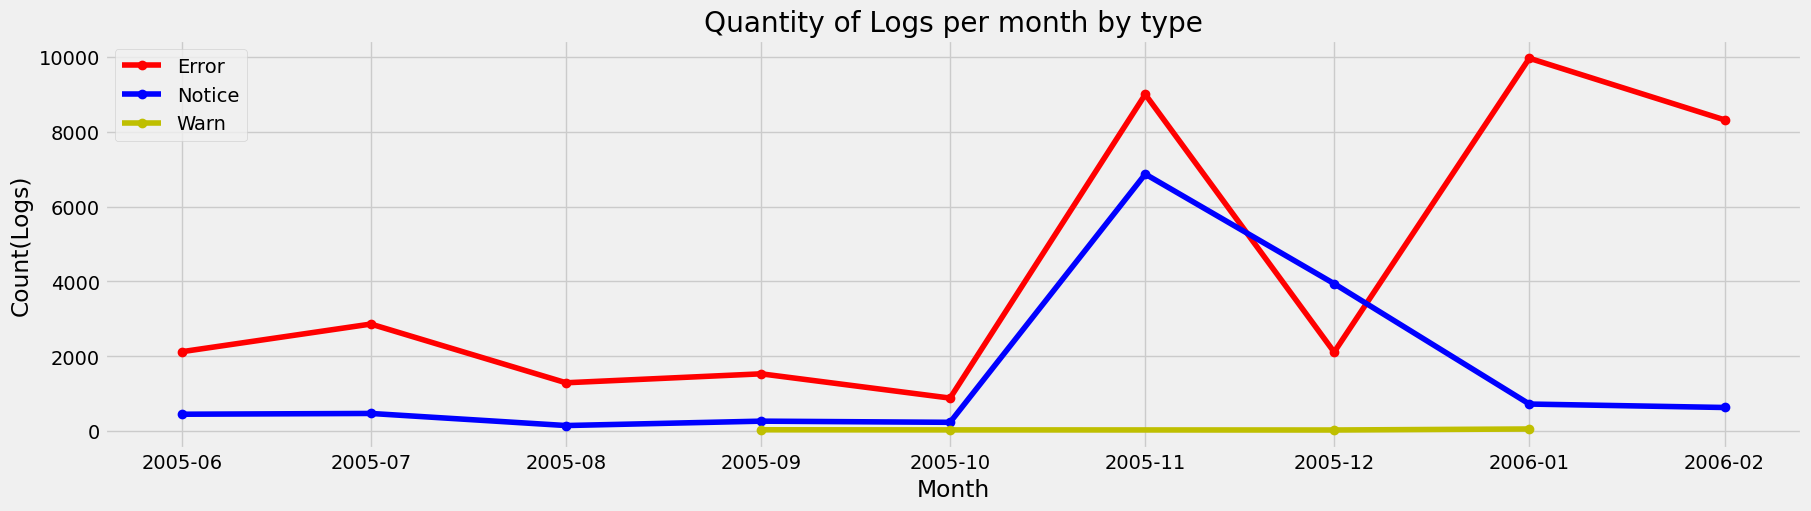

<Figure size 640x480 with 0 Axes>

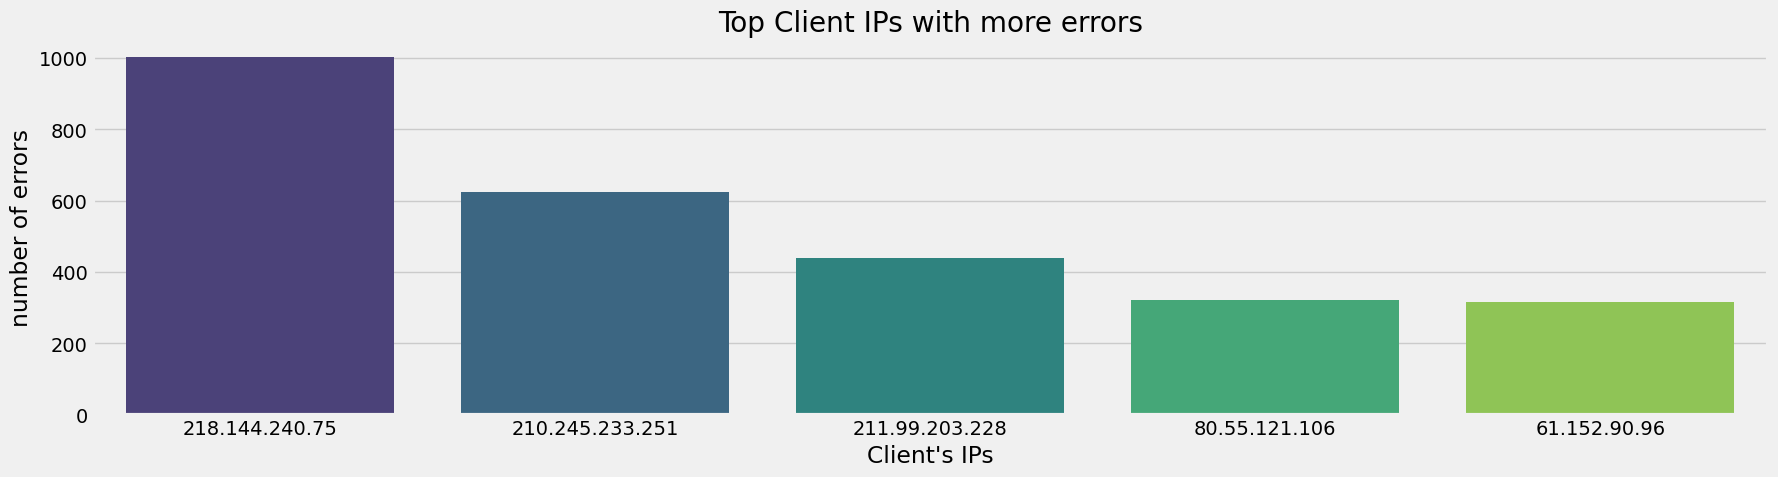

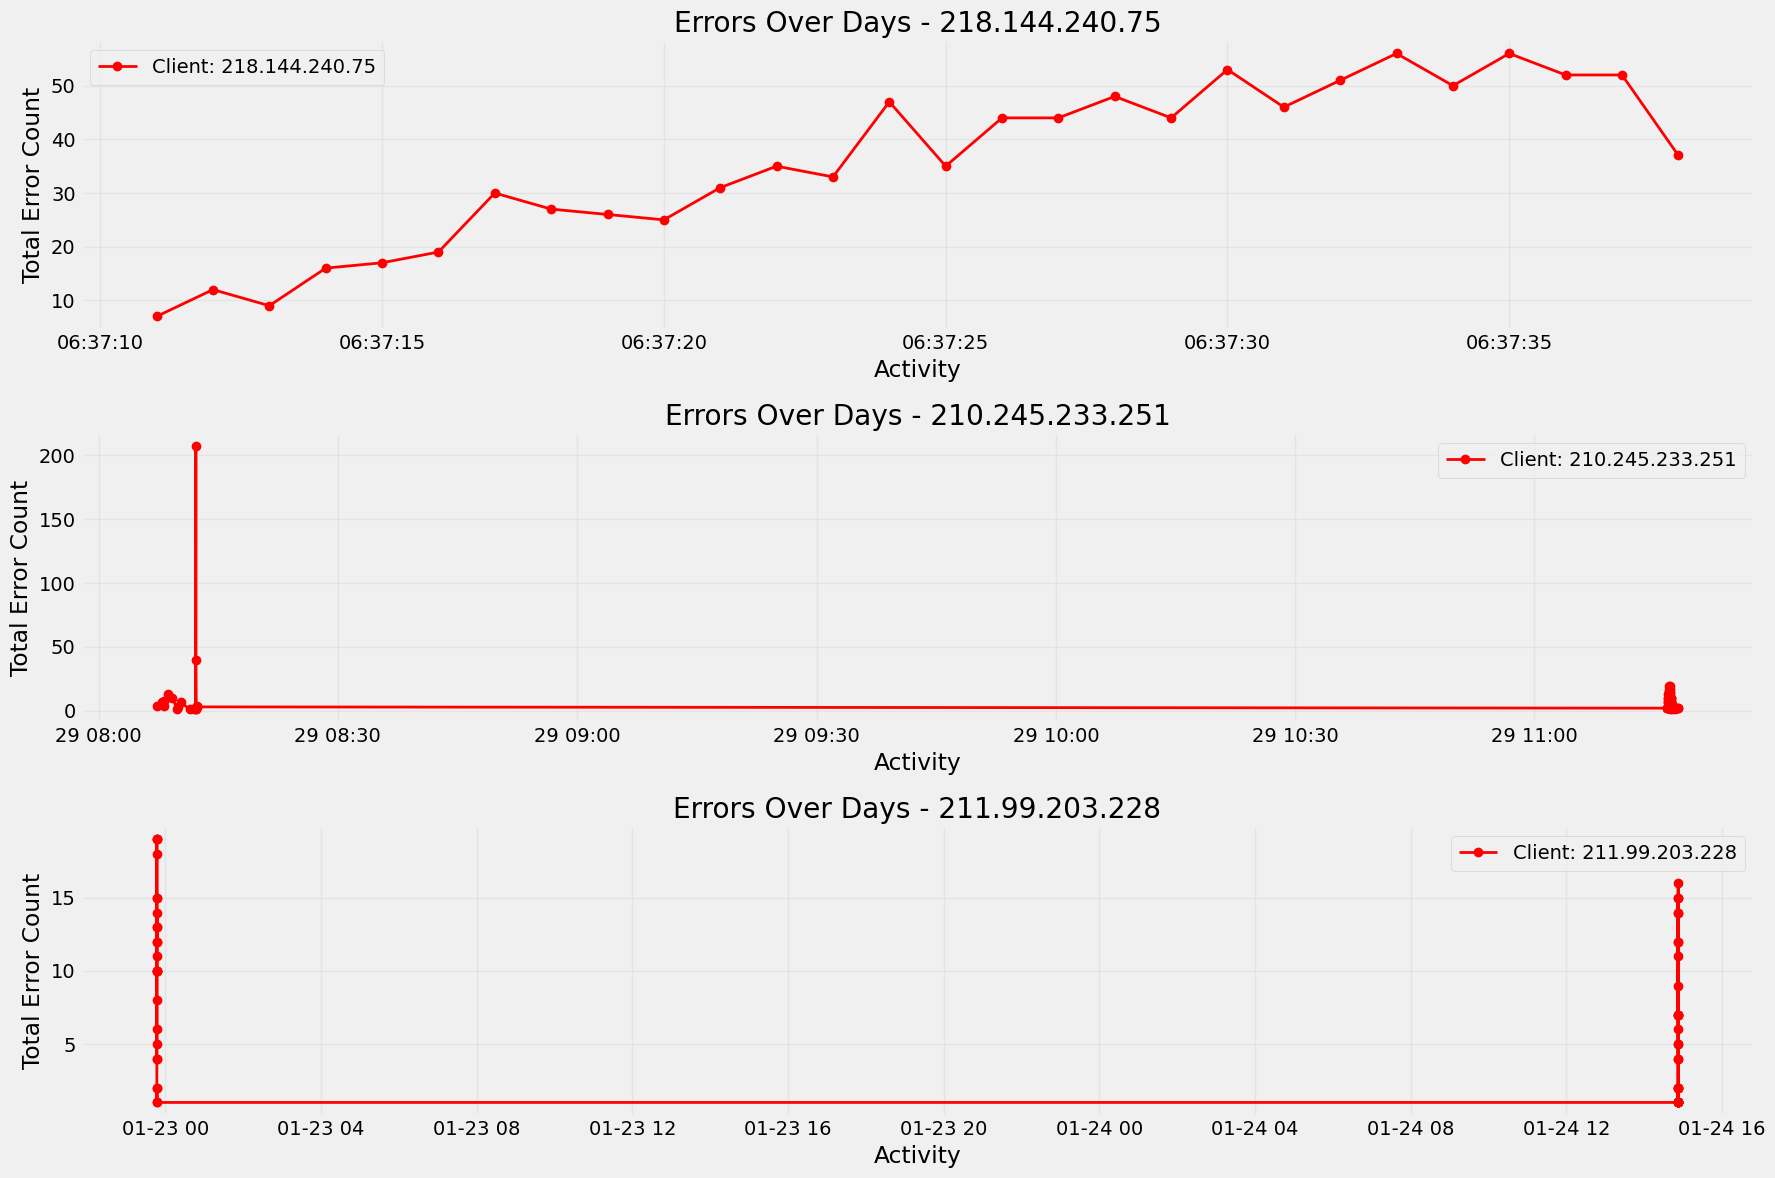

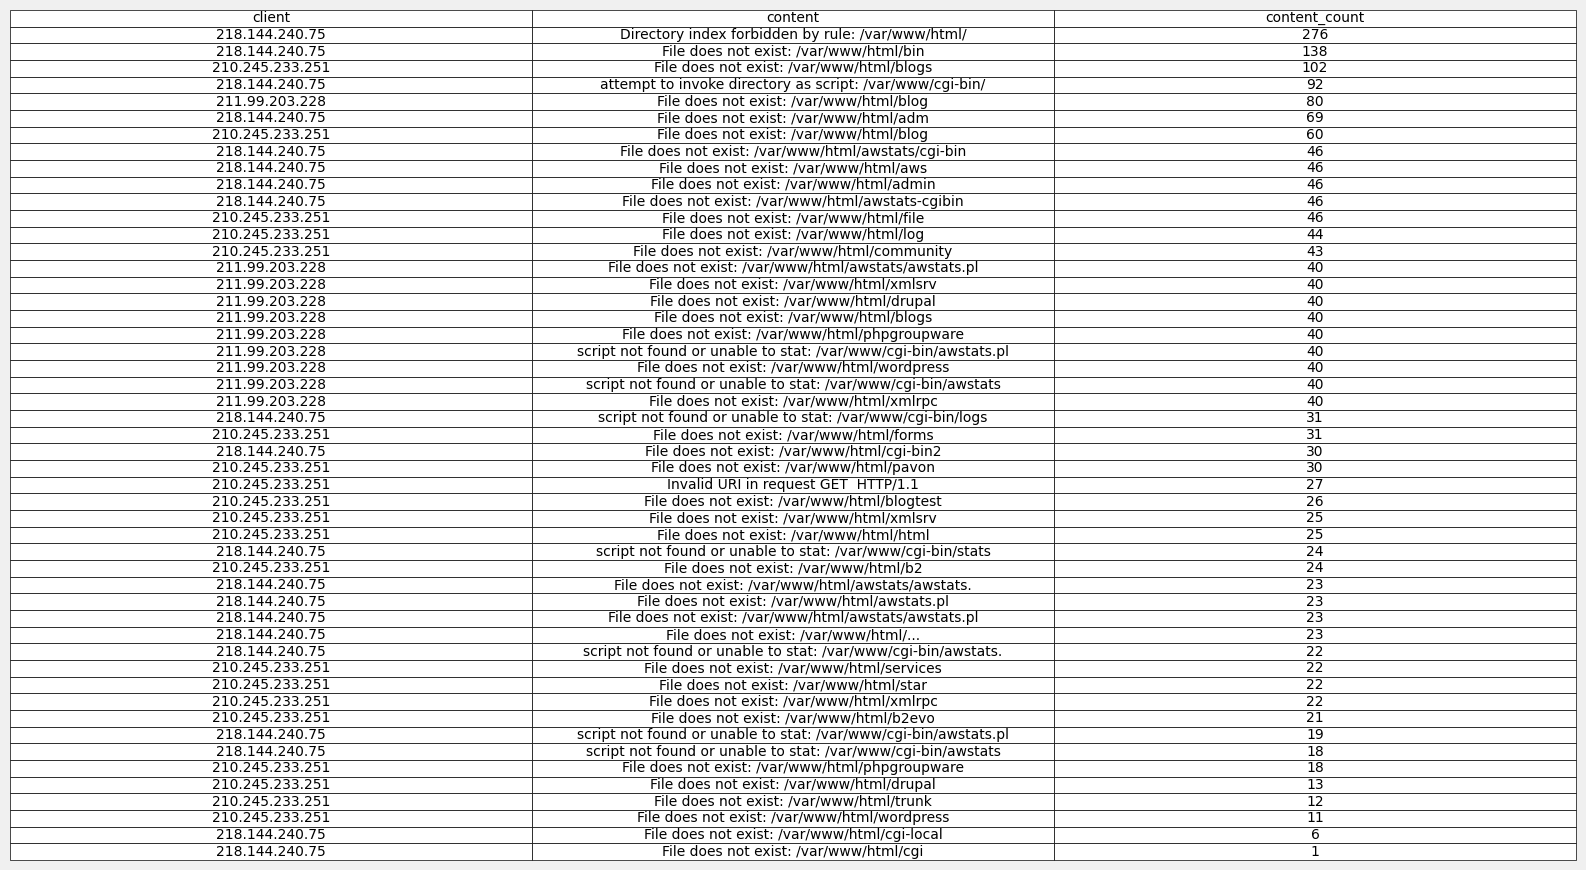

In [ ]:
fig1 = plt.figure()
plt.style.use('fivethirtyeight')
err_df=count_by_date_df.filter(pl.col("type")=="error")
not_df=count_by_date_df.filter(pl.col("type")=="notice")
warn_df=count_by_date_df.filter(pl.col("type")=="warn")
plt.figure(figsize=(18, 5), layout='constrained')
plt.plot(err_df['year_month'], err_df["type_count"], marker='o', label='Error', c='r')
plt.plot(not_df['year_month'], not_df["type_count"], marker='o', label='Notice', c='b')
plt.plot(warn_df['year_month'], warn_df["type_count"], marker='o', label='Warn', c='y')
plt.xlabel('Month')
plt.ylabel('Count(Logs)')
plt.title('Quantity of Logs per month by type')
plt.legend()
display(fig1)

fig2 = plt.figure()
plt.figure(figsize=(18,5), layout='constrained')
sns.barplot(x= client_df['client'],y=client_df['type_count'], palette='viridis')
plt.xlabel("Client's IPs")
plt.ylabel("number of errors")
plt.title('Top Client IPs with more errors')
plt.tight_layout()


display(fig2)

top_clients = client_df['client'].to_list()
# Create subplots
fig3, axes = plt.subplots(len(top_clients[0:3]), 1, figsize=(18, 4 * len(top_clients[0:3])), layout='constrained')
plt.style.use('fivethirtyeight')

# Process each client
for idx, client in enumerate(top_clients[0:3]):
    client_dfs = err_by_ip_and_date_df.filter(pl.col("client") == client)
  
    daily_errors = client_dfs.group_by("date").agg(pl.col("type_count").sum()).sort("date")

    dates = daily_errors.get_column("date")
    error_counts = daily_errors.get_column("type_count")
    
    axes[idx].plot(dates, error_counts, marker='o', label=f'Client: {client}', c='r', linewidth=2)
    axes[idx].set_xlabel('Activity')
    axes[idx].set_ylabel('Total Error Count')
    axes[idx].set_title(f'Errors Over Days - {client}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig4, ax = plt.subplots(figsize=(18, 6)) # Adjust figure size as needed

# Hide axes for a clean table-only image
ax.axis('off')
ax.axis('tight')

ax.table(cellText=activity_of_ip_count.to_pandas().values, colLabels=activity_of_ip_count.to_pandas().columns, loc='center', cellLoc='center')
